In [36]:
import pandas as pd

In [37]:
caminho = r"C:\Projetos\LearningDataAnalysis\dados\microdados_enem_2018\DADOS\MICRODADOS_ENEM_2018.csv"

In [38]:
microdadosEnem = pd.read_csv(caminho, sep=";", encoding='ISO-8859-1')

In [39]:
colunasSelecionadas = ['NU_INSCRICAO', 'NU_NOTA_MT', 'NU_NOTA_REDACAO', 'Q001', 'Q002']

In [40]:
microdadosEnem.columns.values

<StringArray>
[          'NU_INSCRICAO',                 'NU_ANO',        'TP_FAIXA_ETARIA',
                'TP_SEXO',        'TP_ESTADO_CIVIL',            'TP_COR_RACA',
       'TP_NACIONALIDADE',        'TP_ST_CONCLUSAO',        'TP_ANO_CONCLUIU',
              'TP_ESCOLA',              'TP_ENSINO',           'IN_TREINEIRO',
       'CO_MUNICIPIO_ESC',       'NO_MUNICIPIO_ESC',              'CO_UF_ESC',
              'SG_UF_ESC', 'TP_DEPENDENCIA_ADM_ESC',     'TP_LOCALIZACAO_ESC',
        'TP_SIT_FUNC_ESC',     'CO_MUNICIPIO_PROVA',     'NO_MUNICIPIO_PROVA',
            'CO_UF_PROVA',            'SG_UF_PROVA',         'TP_PRESENCA_CN',
         'TP_PRESENCA_CH',         'TP_PRESENCA_LC',         'TP_PRESENCA_MT',
            'CO_PROVA_CN',            'CO_PROVA_CH',            'CO_PROVA_LC',
            'CO_PROVA_MT',             'NU_NOTA_CN',             'NU_NOTA_CH',
             'NU_NOTA_LC',             'NU_NOTA_MT',        'TX_RESPOSTAS_CN',
        'TX_RESPOSTAS_CH',        'TX_

In [43]:
microdadosEnemSelecionado = microdadosEnem.filter(items = colunasSelecionadas).dropna()

In [44]:
microdadosEnemSelecionado.head()

,NU_INSCRICAO,NU_NOTA_MT,NU_NOTA_REDACAO,Q001,Q002
0,180007186625,496.3,360.0,E,E
1,180007186627,440.6,420.0,D,E
2,180007186628,410.4,600.0,B,B
3,180007186629,711.5,800.0,F,F
4,180007186631,543.1,500.0,A,E


Definindo um Dicionário

In [48]:
q001e002Dicionario = {
'A': 'Nunca Estudou',
'B': 'Não completou a 4ª série/5º ano do Ensino Fundamental.',
'C': 'Completou a 4ª série/5º ano, mas não completou a 8ª série/9º ano do Ensino Fundamental.',
'D': 'Completou a 8ª série/9º ano do Ensino Fundamental, mas não completou o Ensino Médio.',
'E': 'Completou o Ensino Médio, mas não completou a Faculdade.',
'F': 'Completou a Faculdade, mas não completou a Pós-graduação.',
'G': 'Completou a Pós-graduação.',
'H': 'Não sei.'
}

In [49]:
microdadosEnemSelecionado.filter(items = ['Q001', 'NU_INSCRICAO']).groupby('Q001').count()

,NU_INSCRICAO
Q001,
A,200900
B,813670
C,549966
D,460450
E,1043471
F,311916
G,187704
H,325652


aqui faremos a criação de uma nova coluna para melhor visualizacao dos dados
a partir da biblioteca

In [50]:
microdadosEnemSelecionado['NO_Q001'] = [q001e002Dicionario[resp] for resp in microdadosEnemSelecionado.Q001]

In [54]:
q001e002Dicionario['A'] 

'Nunca Estudou'

In [55]:
q001e002Dicionario['B'] 

'Não completou a 4ª série/5º ano do Ensino Fundamental.'

In [ ]:
microdadosEnemSelecionado.Q001.head()

In [58]:
microdadosEnemSelecionado.head()

,NU_INSCRICAO,NU_NOTA_MT,NU_NOTA_REDACAO,Q001,Q002,NO_Q001
0,180007186625,496.3,360.0,E,E,"Completou o Ensino Médio, mas não completou a ..."
1,180007186627,440.6,420.0,D,E,Completou a 8ª série/9º ano do Ensino Fundamen...
2,180007186628,410.4,600.0,B,B,Não completou a 4ª série/5º ano do Ensino Fund...
3,180007186629,711.5,800.0,F,F,"Completou a Faculdade, mas não completou a Pós..."
4,180007186631,543.1,500.0,A,E,Nunca Estudou


agora fazendo para a questao 2

In [60]:
microdadosEnemSelecionado.filter(items = ['Q002', 'NU_INSCRICAO']).groupby('Q002').count()

,NU_INSCRICAO
Q002,
A,136414
B,606702
C,515982
D,509542
E,1275070
F,417223
G,322694
H,110102


criando uma nova coluna que expoe as informações correspondentes das respostas de letras.

In [61]:
microdadosEnemSelecionado['NO_Q002'] = [q001e002Dicionario[resp] for resp in microdadosEnemSelecionado.Q002]

In [62]:
q001e002Dicionario['A'] 

'Nunca Estudou'

In [63]:
microdadosEnemSelecionado.Q002.head()

0    E
1    E
2    B
3    F
4    E
Name: Q002, dtype: str

In [64]:
microdadosEnemSelecionado.head()

,NU_INSCRICAO,NU_NOTA_MT,NU_NOTA_REDACAO,Q001,Q002,NO_Q001,NO_Q002
0,180007186625,496.3,360.0,E,E,"Completou o Ensino Médio, mas não completou a ...","Completou o Ensino Médio, mas não completou a ..."
1,180007186627,440.6,420.0,D,E,Completou a 8ª série/9º ano do Ensino Fundamen...,"Completou o Ensino Médio, mas não completou a ..."
2,180007186628,410.4,600.0,B,B,Não completou a 4ª série/5º ano do Ensino Fund...,Não completou a 4ª série/5º ano do Ensino Fund...
3,180007186629,711.5,800.0,F,F,"Completou a Faculdade, mas não completou a Pós...","Completou a Faculdade, mas não completou a Pós..."
4,180007186631,543.1,500.0,A,E,Nunca Estudou,"Completou o Ensino Médio, mas não completou a ..."


Visualizar a quantidade de respostas sobre a escolaridade do pai

In [73]:
microdadosEnemSelecionado.filter(items = ['NU_INSCRICAO', 'NO_Q001']).groupby('NO_Q001').count().sort_values(by='NU_INSCRICAO', ascending=False)

,NU_INSCRICAO
NO_Q001,
"Completou o Ensino Médio, mas não completou a Faculdade.",1043471
Não completou a 4ª série/5º ano do Ensino Fundamental.,813670
"Completou a 4ª série/5º ano, mas não completou a 8ª série/9º ano do Ensino Fundamental.",549966
"Completou a 8ª série/9º ano do Ensino Fundamental, mas não completou o Ensino Médio.",460450
Não sei.,325652
"Completou a Faculdade, mas não completou a Pós-graduação.",311916
Nunca Estudou,200900
Completou a Pós-graduação.,187704


visualizar a quantidade de respostas sobre a escolaridade da mae

In [70]:
microdadosEnemSelecionado.filter(items = ['NU_INSCRICAO', 'NO_Q002']).groupby('NO_Q002').count().sort_values(by='NU_INSCRICAO', ascending=False)

,NU_INSCRICAO
NO_Q002,
"Completou o Ensino Médio, mas não completou a Faculdade.",1275070
Não completou a 4ª série/5º ano do Ensino Fundamental.,606702
"Completou a 4ª série/5º ano, mas não completou a 8ª série/9º ano do Ensino Fundamental.",515982
"Completou a 8ª série/9º ano do Ensino Fundamental, mas não completou o Ensino Médio.",509542
"Completou a Faculdade, mas não completou a Pós-graduação.",417223
Completou a Pós-graduação.,322694
Nunca Estudou,136414
Não sei.,110102


visualizar a resposta sobre a escolaridade do pai dependendo da nota de matematica

In [75]:
microdadosEnemSelecionado.filter(items = ['NU_NOTA_MT', 'NO_Q001']).groupby('NO_Q001').mean().sort_values(by='NU_NOTA_MT', ascending=False)

,NU_NOTA_MT
NO_Q001,
Completou a Pós-graduação.,628.857905
"Completou a Faculdade, mas não completou a Pós-graduação.",606.912178
"Completou o Ensino Médio, mas não completou a Faculdade.",550.922637
"Completou a 8ª série/9º ano do Ensino Fundamental, mas não completou o Ensino Médio.",530.540003
"Completou a 4ª série/5º ano, mas não completou a 8ª série/9º ano do Ensino Fundamental.",519.449784
Não sei.,512.677316
Não completou a 4ª série/5º ano do Ensino Fundamental.,502.412921
Nunca Estudou,483.409593


visualizar a resposta sobre a escolaridade da mae dependendo da nota de matematica

In [76]:
microdadosEnemSelecionado.filter(items = ['NU_NOTA_MT', 'NO_Q002']).groupby('NO_Q002').mean().sort_values(by='NU_NOTA_MT', ascending=False)

,NU_NOTA_MT
NO_Q002,
Completou a Pós-graduação.,604.646106
"Completou a Faculdade, mas não completou a Pós-graduação.",591.438418
"Completou o Ensino Médio, mas não completou a Faculdade.",541.991102
"Completou a 8ª série/9º ano do Ensino Fundamental, mas não completou o Ensino Médio.",521.292700
"Completou a 4ª série/5º ano, mas não completou a 8ª série/9º ano do Ensino Fundamental.",512.046346
Não sei.,504.109545
Não completou a 4ª série/5º ano do Ensino Fundamental.,497.003174
Nunca Estudou,478.218055


olhando o desempenho da redaçao segundo a escolaridade do mae e do pai

In [77]:
microdadosEnemSelecionado.filter(items = ['NU_NOTA_REDACAO', 'NO_Q001']).groupby('NO_Q001').mean().sort_values(by='NU_NOTA_REDACAO', ascending=False)

,NU_NOTA_REDACAO
NO_Q001,
Completou a Pós-graduação.,652.213592
"Completou a Faculdade, mas não completou a Pós-graduação.",622.430783
"Completou o Ensino Médio, mas não completou a Faculdade.",544.272031
"Completou a 8ª série/9º ano do Ensino Fundamental, mas não completou o Ensino Médio.",511.710457
"Completou a 4ª série/5º ano, mas não completou a 8ª série/9º ano do Ensino Fundamental.",492.833448
Não sei.,474.283775
Não completou a 4ª série/5º ano do Ensino Fundamental.,464.490076
Nunca Estudou,427.259532


In [78]:
microdadosEnemSelecionado.filter(items = ['NU_NOTA_REDACAO', 'NO_Q002']).groupby('NO_Q002').mean().sort_values(by='NU_NOTA_REDACAO', ascending=False)

,NU_NOTA_REDACAO
NO_Q002,
Completou a Pós-graduação.,622.779227
"Completou a Faculdade, mas não completou a Pós-graduação.",601.241398
"Completou o Ensino Médio, mas não completou a Faculdade.",530.014948
"Completou a 8ª série/9º ano do Ensino Fundamental, mas não completou o Ensino Médio.",495.963591
"Completou a 4ª série/5º ano, mas não completou a 8ª série/9º ano do Ensino Fundamental.",479.675260
Não completou a 4ª série/5º ano do Ensino Fundamental.,454.591612
Não sei.,447.200959
Nunca Estudou,414.232410


In [79]:
q002redacao = microdadosEnemSelecionado.filter(items = ['NU_NOTA_REDACAO', 'NO_Q002']).groupby('NO_Q002').mean().sort_values(by='NU_NOTA_REDACAO', ascending=False)

<Axes: xlabel='NO_Q002'>

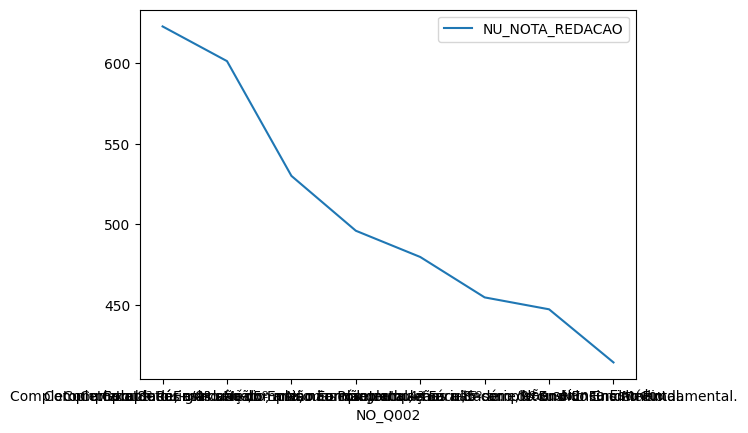

In [80]:
q002redacao.plot()

In [83]:
microdadosEnemSelecionado.filter(items = ['NU_NOTA_REDACAO', 'NO_Q002']).groupby('NO_Q002').describe()

NU_NOTA_REDACAO  \
                                                             count   
NO_Q002                                                              
Completou a 4ª série/5º ano, mas não completou ...        515982.0   
Completou a 8ª série/9º ano do Ensino Fundament...        509542.0   
Completou a Faculdade, mas não completou a Pós-...        417223.0   
Completou a Pós-graduação.                                322694.0   
Completou o Ensino Médio, mas não completou a F...       1275070.0   
Nunca Estudou                                             136414.0   
Não completou a 4ª série/5º ano do Ensino Funda...        606702.0   
Não sei.                                                  110102.0   

                                                                            \
                                                          mean         std   
NO_Q002                                                                      
Completou a 4ª série/5º ano, mas não completou ...  479.675260  169.431630   
Completou a 8ª série/9º ano do Ensino Fundament...  495.963591  172.446160   
Completou a Faculdade, mas não completou a Pós-...  601.241398  186.788498   
Completou a Pós-graduação.                          622.779227  188.933534   
Completou o Ensino Médio, mas não completou a F...  530.014948  178.594201   
Nunca Estudou                                       414.232410  164.949189   
Não completou a 4ª série/5º ano do Ensino Funda...  454.591612  163.877470   
Não sei.                                            447.200959  180.135582   

                                                                              \
                                                    min    25%    50%    75%   
NO_Q002                                                                        
Completou a 4ª série/5º ano, mas não completou ...  0.0  360.0  480.0  600.0   
Completou a 8ª série/9º ano do Ensino Fundament...  0.0  360.0  500.0  600.0   
Completou a Faculdade, mas não completou a Pós-...  0.0  480.0  600.0  740.0   
Completou a Pós-graduação.                          0.0  500.0  620.0  760.0   
Completou o Ensino Médio, mas não completou a F...  0.0  380.0  540.0  640.0   
Nunca Estudou                                       0.0  320.0  380.0  540.0   
Não completou a 4ª série/5º ano do Ensino Funda...  0.0  340.0  460.0  560.0   
Não sei.                                            0.0  320.0  440.0  560.0   

                                                            
                                                       max  
NO_Q002                                                     
Completou a 4ª série/5º ano, mas não completou ...  1000.0  
Completou a 8ª série/9º ano do Ensino Fundament...  1000.0  
Completou a Faculdade, mas não completou a Pós-...  1000.0  
Completou a Pós-graduação.                          1000.0  
Completou o Ensino Médio, mas não completou a F...  1000.0  
Nunca Estudou                                        980.0  
Não completou a 4ª série/5º ano do Ensino Funda...   980.0  
Não sei.                                             980.0

Analisando dados socioeconomicos por estados